# Sales Prediction

### Importing Libraries

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Reading

In [158]:
adv = pd.read_excel(r"C:\Users\USER\Downloads\Ecommerce Sales Dataset.xlsx")
adv.head()

,OrderID,CustomerID,Product,Category,Quantity,Price,OrderDate,Month,Region,Revenue,Recency
0,O0001,C041,Laptop,Electronics,1,350,2025-03-12,March,South,350,199
1,O0002,C015,Smartphone,Electronics,1,350,2025-07-09,July,North,350,80
2,O0003,C038,Camera,Electronics,1,500,2025-01-24,January,South,500,246
3,O0004,C015,Smartwatch,Electronics,5,500,2025-05-24,May,South,2500,126
4,O0005,C046,Tablet,Electronics,5,400,2025-02-26,February,West,2000,213


In [6]:
adv.shape

(200, 11)

In [7]:
adv.isnull().sum()

OrderID       0
CustomerID    0
Product       0
Category      0
Quantity      0
Price         0
OrderDate     0
Month         0
Region        0
Revenue       0
Recency       0
dtype: int64

In [9]:
adv.dtypes

OrderID               object
CustomerID            object
Product               object
Category              object
Quantity               int64
Price                  int64
OrderDate     datetime64[ns]
Month                 object
Region                object
Revenue                int64
Recency                int64
dtype: object

In [10]:
for i in adv.columns:
 print(i,':','\n',adv[i].unique())

OrderID : 
 ['O0001' 'O0002' 'O0003' 'O0004' 'O0005' 'O0006' 'O0007' 'O0008' 'O0009'
 'O0010' 'O0011' 'O0012' 'O0013' 'O0014' 'O0015' 'O0016' 'O0017' 'O0018'
 'O0019' 'O0020' 'O0021' 'O0022' 'O0023' 'O0024' 'O0025' 'O0026' 'O0027'
 'O0028' 'O0029' 'O0030' 'O0031' 'O0032' 'O0033' 'O0034' 'O0035' 'O0036'
 'O0037' 'O0038' 'O0039' 'O0040' 'O0041' 'O0042' 'O0043' 'O0044' 'O0045'
 'O0046' 'O0047' 'O0048' 'O0049' 'O0050' 'O0051' 'O0052' 'O0053' 'O0054'
 'O0055' 'O0056' 'O0057' 'O0058' 'O0059' 'O0060' 'O0061' 'O0062' 'O0063'
 'O0064' 'O0065' 'O0066' 'O0067' 'O0068' 'O0069' 'O0070' 'O0071' 'O0072'
 'O0073' 'O0074' 'O0075' 'O0076' 'O0077' 'O0078' 'O0079' 'O0080' 'O0081'
 'O0082' 'O0083' 'O0084' 'O0085' 'O0086' 'O0087' 'O0088' 'O0089' 'O0090'
 'O0091' 'O0092' 'O0093' 'O0094' 'O0095' 'O0096' 'O0097' 'O0098' 'O0099'
 'O0100' 'O0101' 'O0102' 'O0103' 'O0104' 'O0105' 'O0106' 'O0107' 'O0108'
 'O0109' 'O0110' 'O0111' 'O0112' 'O0113' 'O0114' 'O0115' 'O0116' 'O0117'
 'O0118' 'O0119' 'O0120' 'O0121' 'O0122

## Data Analysis

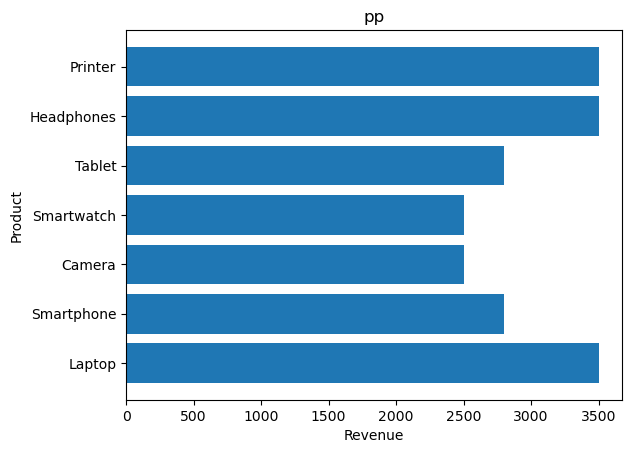

In [19]:
plt.barh(adv['Product'], adv['Revenue'], )
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Revenue by Product')
plt.show()

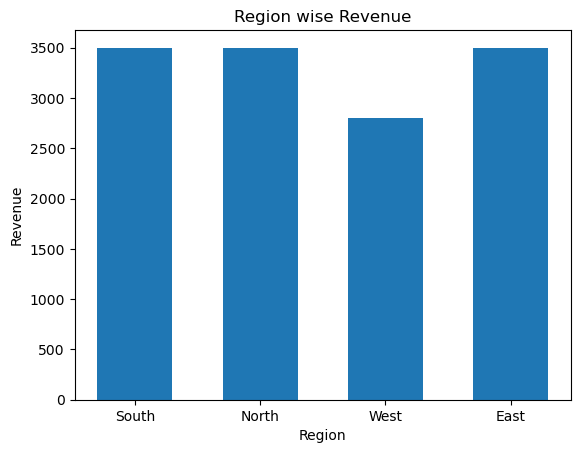

In [26]:
plt.bar(adv['Region'], adv['Revenue'], width=0.6)
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.title('Region wise Revenue')
plt.show()

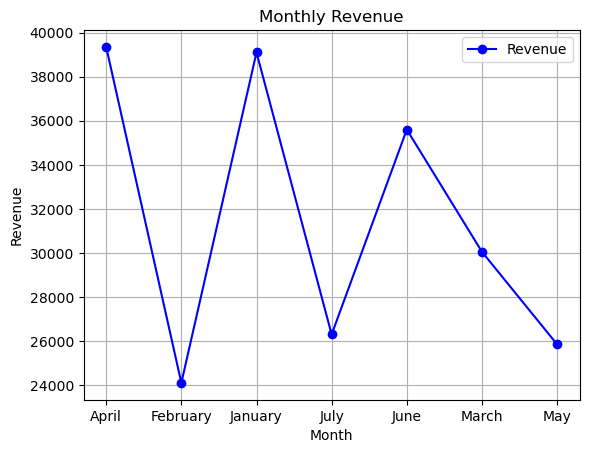

In [29]:
monthly_revenue = adv.groupby('Month')['Revenue'].sum()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='blue', label="Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.legend() 
plt.grid(True) 
plt.show()

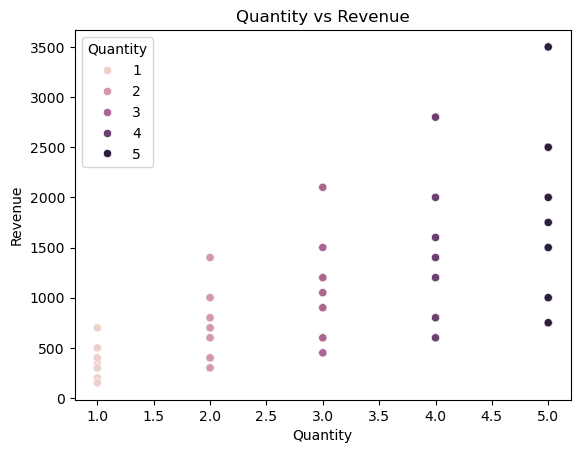

In [31]:
sns.scatterplot(x=adv['Quantity'],y=adv['Revenue'],hue=adv['Quantity'])
plt.title('Quantity vs Revenue')
plt.show()

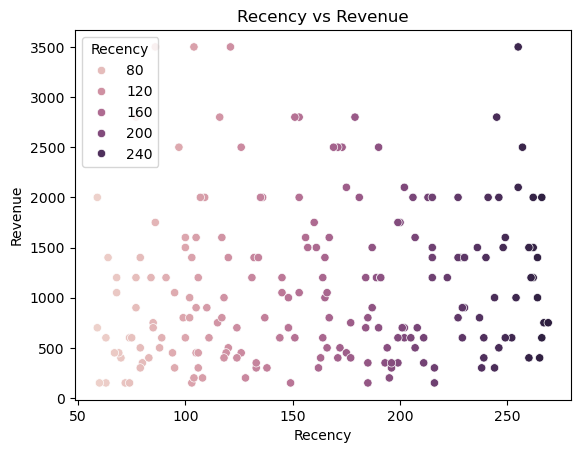

In [32]:
sns.scatterplot(x=adv['Recency'],y=adv['Revenue'],hue=adv['Recency'])
plt.title('Recency vs Revenue')
plt.show()

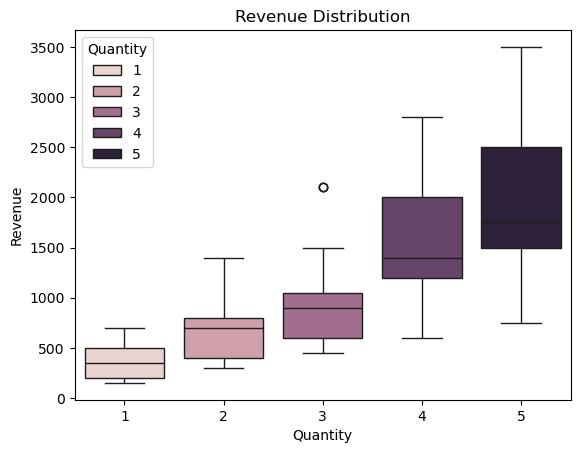

In [37]:
sns.boxplot(x=adv['Quantity'],y=adv['Revenue'],hue=adv['Quantity'])
plt.title('Revenue Distribution')
plt.show()

### Heat map

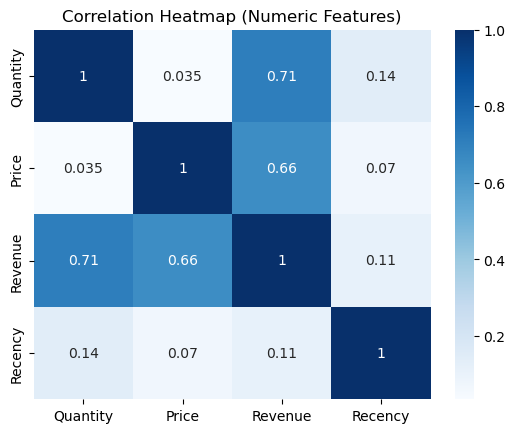

In [40]:
numeric_adv = adv.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_adv.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

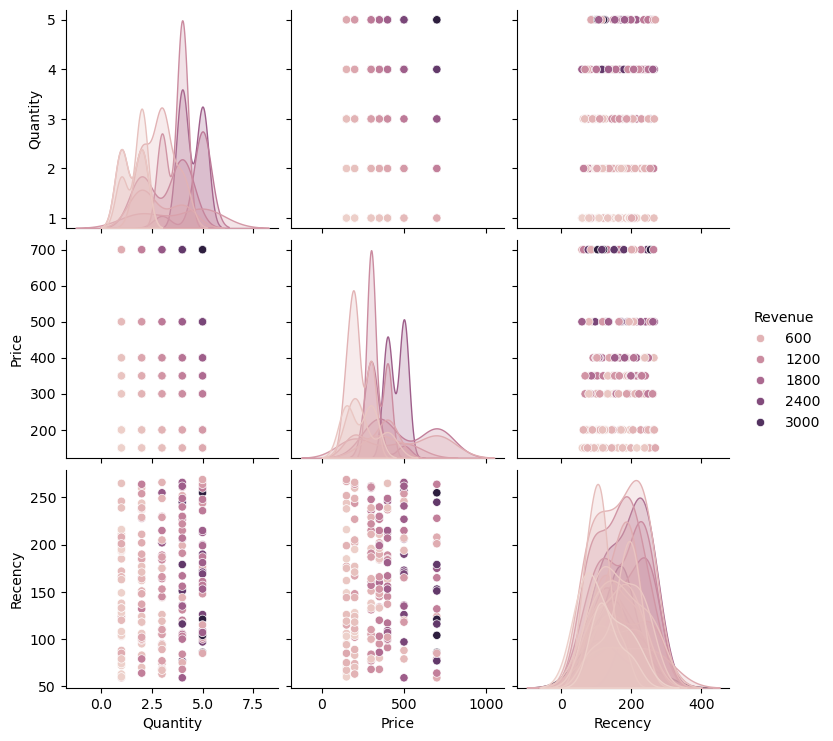

In [41]:
sns.pairplot(adv,hue='Revenue')
plt.show()

### Dropping columns

In [159]:
adv = adv.drop(['Category', 'OrderDate', 'OrderID', 'CustomerID'], axis=1)

### Encoding

In [160]:
adv = pd.get_dummies(adv, columns=['Product', 'Month', 'Region'])

In [161]:
adv.dtypes

Quantity              int64
Price                 int64
Revenue               int64
Recency               int64
Product_Camera         bool
Product_Headphones     bool
Product_Laptop         bool
Product_Printer        bool
Product_Smartphone     bool
Product_Smartwatch     bool
Product_Tablet         bool
Month_April            bool
Month_February         bool
Month_January          bool
Month_July             bool
Month_June             bool
Month_March            bool
Month_May              bool
Region_East            bool
Region_North           bool
Region_South           bool
Region_West            bool
dtype: object

In [162]:
bool_cols = adv.select_dtypes(include="bool").columns
adv[bool_cols] = adv[bool_cols].astype(int)

In [163]:
adv.head()

,Quantity,Price,Revenue,Recency,Product_Camera,Product_Headphones,Product_Laptop,Product_Printer,Product_Smartphone,Product_Smartwatch,...,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Region_East,Region_North,Region_South,Region_West
0,1,350,350,199,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,1,350,350,80,0,0,0,0,1,0,...,0,0,1,0,0,0,0,1,0,0
2,1,500,500,246,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
3,5,500,2500,126,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
4,5,400,2000,213,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


### ip and op creation

In [164]:
ip = adv.drop('Revenue',axis=1)
op = adv.Revenue

In [165]:
ip.head()

,Quantity,Price,Recency,Product_Camera,Product_Headphones,Product_Laptop,Product_Printer,Product_Smartphone,Product_Smartwatch,Product_Tablet,...,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Region_East,Region_North,Region_South,Region_West
0,1,350,199,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,1,350,80,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
2,1,500,246,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
3,5,500,126,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
4,5,400,213,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1


In [166]:
op.head()

0     350
1     350
2     500
3    2500
4    2000
Name: Revenue, dtype: int64

### Train test split

In [167]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(ip,op,test_size=0.2)

### Standard Scaler

In [168]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

## machine learning model

In [169]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

## Prediction

In [170]:
ypred = lr.predict(x_test)

In [171]:
#Accuracy,r2score,mean squared error
from sklearn.metrics import r2_score,mean_squared_error
r2 = r2_score(ypred,y_test)
mse = mean_squared_error(ypred,y_test)
print('R2 score is :',r2)
print('Mean Squared Error is :',mse)

R2 score is : 0.8808014574634048
Mean Squared Error is : 71422.02092632854


In [172]:
df = pd.DataFrame({'Prediction':ypred,'Actual data':y_test})
df.head()

,Prediction,Actual data
60,1091.390057,1200
15,210.415222,400
21,1039.323531,800
9,2060.494352,2500
98,478.268839,500


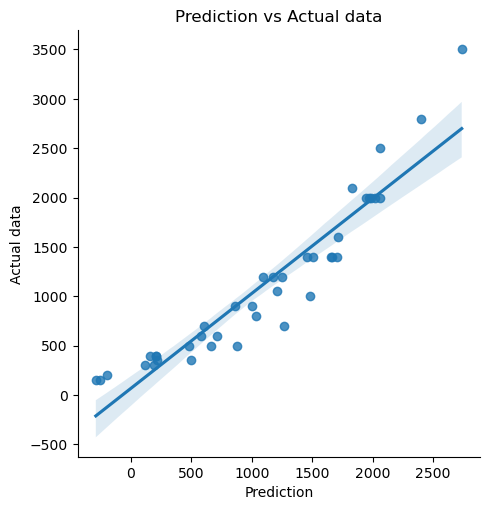

In [174]:
sns.lmplot(df,x='Prediction',y='Actual data')
plt.title('Prediction vs Actual data')
plt.show()